# Exercício Regressão Linear com PyTorch

O objetivo desse notebook é reescrevê-lo porém utilizando tensores do PyTorch.

Os nomes das funções do PyTorch são próximas das funções do Torch original escrito
na linguagem Lua, porém não são iguais.

## Importação dos pacotes

In [26]:
%matplotlib inline
import torch

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

def print_assert(r):
    if r:
        return 'OK!'
    else:
        return 'Incorreto!'

## Dataset

### Leitura dos dados

In [27]:
import pandas as pd
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_in = data[:,0:1]
y_in = data[:,1:2]

x_train = torch.FloatTensor(x_in)
y_train = torch.FloatTensor(y_in)

n_samples = x_train.size(0)
print('x_train.shape:',x_train.shape, type(x_train))
print('y_train.shape:',y_train.shape, type(y_train))

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

iris_pd = pd.DataFrame(x_in, columns=['x_in'])
iris_pd['y_in'] = y_in
iris_pd.head()

x_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
y_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
x_train[:5]:
 tensor([[7.0000],
        [6.4000],
        [6.9000],
        [5.5000],
        [6.5000]])
y_train[:5]:
 tensor([[4.7000],
        [4.5000],
        [4.9000],
        [4.0000],
        [4.6000]])


,x_in,y_in
0,7.0,4.7
1,6.4,4.5
2,6.9,4.9
3,5.5,4.0
4,6.5,4.6


### Normalização dos dados

Text(0, 0.5, 'Comprimento petalas')

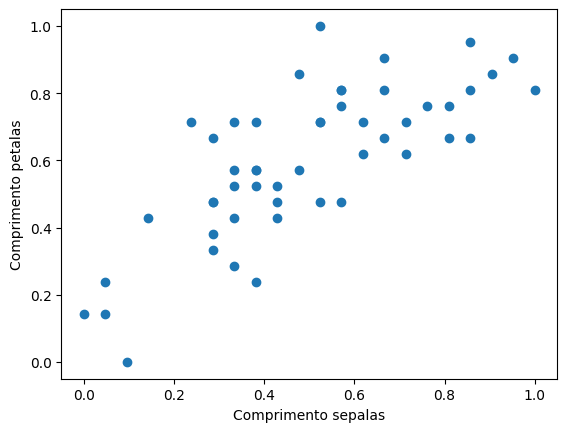

In [28]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

### Exercício 1 - Criação do `x_train_bias`

faça o `x_train_bias` ser uma matriz com 1s na primeira coluna e x_train na segunda coluna.




Dica: você pode precisar da função [torch.cat](http://pytorch.org/docs/master/torch.html#torch.cat) e [torch.ones](http://pytorch.org/docs/master/torch.html#torch.ones).

In [46]:
# @title Documentação torch.ones
print(help(torch.ones))

Help on built-in function ones in module torch:

ones(...)
    ones(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor

    Returns a tensor filled with the scalar value `1`, with the shape defined
    by the variable argument :attr:`size`.

    Args:
        size (int...): a sequence of integers defining the shape of the output tensor.
            Can be a variable number of arguments or a collection like a list or tuple.

    Keyword arguments:
        out (Tensor, optional): the output tensor.
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            Default: if ``None``, uses a global default (see :func:`torch.set_default_dtype`).
        layout (:class:`torch.layout`, optional): the desired layout of returned Tensor.
            Default: ``torch.strided``.
        device (:class:`torch.device`, optional): the desired device of returned tensor.
            Default: if ``None``, uses the curre

In [45]:
# @title Documentação torch.cat
print(help(torch.cat))

Help on built-in function cat in module torch:

cat(...)
    cat(tensors, dim=0, *, out=None) -> Tensor

    Concatenates the given sequence of tensors in :attr:`tensors` in the given dimension.
    All tensors must either have the same shape (except in the concatenating
    dimension) or be a 1-D empty tensor with size ``(0,)``.

    :func:`torch.cat` can be seen as an inverse operation for :func:`torch.split`
    and :func:`torch.chunk`.

    :func:`torch.cat` can be best understood via examples.

    .. seealso::

        :func:`torch.stack` concatenates the given sequence along a new dimension.

    Args:
        tensors (sequence of Tensors): Non-empty tensors provided must have the same shape,
            except in the cat dimension.

        dim (int, optional): the dimension over which the tensors are concatenated

    Keyword args:
        out (Tensor, optional): the output tensor.

    Example::

        >>> x = torch.randn(2, 3)
        >>> x
        tensor([[ 0.6580, -1.096

In [37]:
# TODO
x_train_bias = torch.cat(((torch.ones(50,1)),x_train),dim=1)

In [38]:
# Verificação do exercício - Execute para testar sua implementação

print('x_train_bias é um tensor: {}'.format(print_assert(
    isinstance(x_train_bias, torch.FloatTensor)
)))

print('tamanho do x_train_bias: {}'.format(print_assert(
    x_train_bias.size() == torch.Size([50, 2])
)))

print('primeira coluna é só de uns: {}'.format(print_assert(
    (x_train_bias[:, 0] - torch.ones(n_samples)).sum() == 0
)))

print('segunda coluna é igual a x_train: {}'.format(print_assert(
    (x_train_bias[:, 1] - x_train.reshape(50)).sum() == 0
)))


x_train_bias é um tensor: OK!
tamanho do x_train_bias: OK!
primeira coluna é só de uns: OK!
segunda coluna é igual a x_train: OK!


## Modelo da rede

### Definição da classe

In [33]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = torch.Tensor(n_out, n_in)
        self.w.uniform_(-0.1,0.1) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.matmul(torch.t(self.w))


### Instanciando a rede

In [34]:
model = Net(2,1)

### Testando o predict da rede

In [35]:
model.forward(torch.ones((4,2)))
#model.forward(torch.randn(4,2))

tensor([[-0.1138],
        [-0.1138],
        [-0.1138],
        [-0.1138]])

## Treinamento

### Exercício 2 - Treinamento

Refaça o código de treinamento da rede, mas agora utilizando somente Tensores do PyTorch. Faça o mesmo procedimento que o notebook [LinearRegressionIrisNumPy](LinearRegressionIrisNumPy.ipynb). Para consultar as operações disponíveis no PyTorch use a [documentação do PyTorch](http://pytorch.org/docs/master/torch.html).

Funções que podem ser úteis:
- torch.t
- torch.mean
- torch.matmul

In [44]:
# @title Documentação torch.t
print(help(torch.t))

Help on built-in function t in module torch:

t(...)
    t(input) -> Tensor

    Expects :attr:`input` to be <= 2-D tensor and transposes dimensions 0
    and 1.

    0-D and 1-D tensors are returned as is. When input is a 2-D tensor this
    is equivalent to ``transpose(input, 0, 1)``.

    Args:
        input (Tensor): the input tensor.

    Example::

        >>> x = torch.randn(())
        >>> x
        tensor(0.1995)
        >>> torch.t(x)
        tensor(0.1995)
        >>> x = torch.randn(3)
        >>> x
        tensor([ 2.4320, -0.4608,  0.7702])
        >>> torch.t(x)
        tensor([ 2.4320, -0.4608,  0.7702])
        >>> x = torch.randn(2, 3)
        >>> x
        tensor([[ 0.4875,  0.9158, -0.5872],
                [ 0.3938, -0.6929,  0.6932]])
        >>> torch.t(x)
        tensor([[ 0.4875,  0.3938],
                [ 0.9158, -0.6929],
                [-0.5872,  0.6932]])

    See also :func:`torch.transpose`.

None


In [43]:
# @title Documentação torch.mean
print(help(torch.mean))

Help on built-in function mean in module torch:

mean(...)
    mean(input, *, dtype=None) -> Tensor

    .. note::
        If the `input` tensor is empty, ``torch.mean()`` returns ``nan``.
        This behavior is consistent with NumPy and follows the definition
        that the mean over an empty set is undefined.


    Returns the mean value of all elements in the :attr:`input` tensor. Input must be floating point or complex.

    Args:
        input (Tensor):
          the input tensor, either of floating point or complex dtype

    Keyword args:
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            If specified, the input tensor is casted to :attr:`dtype` before the operation
            is performed. This is useful for preventing data type overflows. Default: None.

    Example::

        >>> a = torch.randn(1, 3)
        >>> a
        tensor([[ 0.2294, -0.5481,  1.3288]])
        >>> torch.mean(a)
        tensor(0.3367)

    .. func

In [42]:
# @title Documentação torch.matmul
print(help(torch.matmul))

Help on built-in function matmul in module torch:

matmul(...)
    matmul(input, other, *, out=None) -> Tensor

    Matrix product of two tensors.

    The behavior depends on the dimensionality of the tensors as follows:

    - If both tensors are 1-dimensional, the dot product (scalar) is returned.
    - If both arguments are 2-dimensional, the matrix-matrix product is returned.
    - If the first argument is 1-dimensional and the second argument is 2-dimensional,
      a 1 is prepended to its dimension for the purpose of the matrix multiply.
      After the matrix multiply, the prepended dimension is removed.
    - If the first argument is 2-dimensional and the second argument is 1-dimensional,
      the matrix-vector product is returned.
    - If both arguments are at least 1-dimensional and at least one argument is
      N-dimensional (where N > 2), then a batched matrix multiply is returned.  If the first
      argument is 1-dimensional, a 1 is prepended to its dimension for the 

In [50]:
from re import X
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    #loss = np.square(y_pred - y_train).mean()
    # TODO
    loss = torch.mean(torch.square(y_pred - y_train))
    # cálculo do gradiente pelas derivadas parciais
    #w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)
    # TODO
    w_grad = torch.matmul(
        (2.0/n_samples) * (torch.t(x_train_bias)),
        torch.matmul(x_train_bias,torch.t(model.w)) - y_train
        )
    # gradiente descendente
    #model.w = model.w - learning_rate * w_grad.T
    # TODO
    model.w = model.w - learning_rate * torch.t(w_grad)
    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss))

Epoch[20/100], loss: 0.021170
Epoch[40/100], loss: 0.021169
Epoch[60/100], loss: 0.021169
Epoch[80/100], loss: 0.021169
Epoch[100/100], loss: 0.021169


## Avaliação

### Predict

In [ ]:
y_pred = model.forward(x_train_bias)
plt.plot(x_train.numpy(), y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train.numpy(), y_pred.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Parâmetro treinado

In [ ]:
print(model.w)

In [ ]:
x_bias = x_train_bias
y = y_train
w_opt = (torch.inverse(x_bias.t().mm(x_bias)).mm(x_bias.t())).mm(y)
print(w_opt.t())